In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from argparse import ArgumentParser
import time 
import warnings
warnings.filterwarnings('ignore')

fig_path = '/Users/harryclark/Desktop/grid_modules/'


In [ ]:
source_path = '/Users/harryclark/Downloads/COHORT12/'

# these are sessions I think have grid modules
mouse_days = {21: [16,21,26],
              20: [25],
              25: [20,21,24,25],
              26: [18,19],
              27: [23,24,26],
              28: [19,23,25],
              29: [19,20,23,25],
            }

# there are all the sessions
mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }


old_detected = []
new_detected = []

for mouse in mouse_days:
    for day in mouse_days[mouse]:
        print(f"Processing mouse {mouse}, day {day} with curation with anatomical brain region")
        '''
        source_path = '/Users/harryclark/Downloads/COHORT12/'
        gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95, source_path=source_path) # subset
        g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                        figpath=fig_path, curate_with_vr=False, curate_with_brain_region=False, source_path=source_path) # create grid modules using HDBSCAN    
        
        if len(g_m_ids) > 1:
            new_detected.append((mouse, day))
      ''' 
        source_path = '/Users/harryclark/Downloads/COHORT12_OLD/'
        gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95, source_path=source_path) # subset
        g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                        figpath=fig_path, curate_with_vr=False, curate_with_brain_region=False, source_path=source_path) # create grid modules using HDBSCAN 
        if len(g_m_ids) > 1:
            old_detected.append((mouse, day))

print(f"Old detected grid modules sessions (n={len(old_detected)}): {old_detected}")
print(f"New detected grid modules sessions (n={len(new_detected)}): {new_detected}")


Processing mouse 26, day 18 without curation with anatomical brain region
26 18
optimal travel lag is 12.362362362362369 cm based on kde of travel at max spatial information
optimal travel lag is 12.362362362362369 cm
there are 79 non_grid and non_spatial_cells
there are 10 grid_cells
there are 64 non grid spatial cells
there are 15 non spatial cells
there are 0 speed cells
there are 89 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'VISp2/3' 'VISp5' 'VISpl5']
for the grid cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'VISpl5']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Only one cluster found, attempting to create a new cluster around centroid
Created a new cluster with 8 points close to centroid at distance < 10
Found 2 modules with HDBSCAN for mouse 26 day 18
for each module , the number of points is: [2 8]


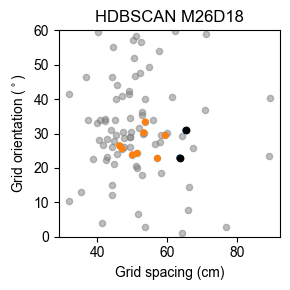

for module 0, there are 8 cells with average spacing 52.39462180923124
Processing mouse 29, day 25 without curation with anatomical brain region
29 25
optimal travel lag is 7.357357357357358 cm based on kde of travel at max spatial information
optimal travel lag is 7.357357357357358 cm
there are 213 non_grid and non_spatial_cells
there are 8 grid_cells
there are 127 non grid spatial cells
there are 86 non spatial cells
there are 0 speed cells
there are 221 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl6a']
for the grid cells the unique locations are ['ENTm3' 'ENTm5']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Only one cluster found, attempting to create a new cluster around centroid
Created a new cluster with 6 points close to centroid at distance < 10
Found 2 modules with HDBSCAN for mouse 29 day 25
for each module , the number of points

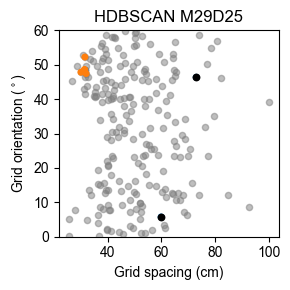

for module 0, there are 6 cells with average spacing 31.31772339068205


In [2]:
mouse_days = {
              26: [18],
              29: [25],
            }

for mouse in mouse_days:
    for day in mouse_days[mouse]:
        print(f"Processing mouse {mouse}, day {day} without curation with anatomical brain region")
        
        source_path = '/Users/harryclark/Downloads/COHORT12_OLD/'
        gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95, source_path=source_path) # subset
        g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                        figpath=fig_path, curate_with_vr=False, curate_with_brain_region=False, source_path=source_path) # create grid modules using HDBSCAN 

In [ ]:
print('hello world')